In [1]:
import numpy as np
import os
import pandas as pd
import xarray as xr
from glob import glob
import matplotlib.pyplot as plt
import itertools as it
from scipy.stats import linregress
from matplotlib.cm import get_cmap
from utils.constants import chamber_levels_complete
import matplotlib.ticker as ticker
import itertools as it
from matplotlib import rcParams
from matplotlib.colors import BoundaryNorm
from utils.analysis import uq_get_obs, uq_get_sim


rcParams['font.size'] = 14
rcParams['axes.titlesize'] = 14

prefix_default = '20231113'
prefix_uptake = '20240321'
prefix_list = [prefix_default, prefix_uptake] # , '20240316_2']

pft_names = ['Spruce', 'Tamarack', 'Shrub']

outdir = os.path.join(os.environ['PROJDIR'], 'ELM_Phenology', 'output', 'extract')

chambers_ordered = {
    'amb': ['6', '20', '13', '8', '17'],
    'elev': ['19', '11', '4', '16', '10']
}

def fit_line(x, y):
    filt = ~np.isnan(x) & ~np.isnan(y)
    x = x[filt]
    y = y[filt]

    if sum(filt) == 0:
        return np.nan, np.nan, np.nan, np.nan, np.nan

    res = linregress(x, y)
    xnew = np.linspace(x.min(), x.max(), 3)
    ynew = res.slope * xnew + res.intercept
    r2 = res.rvalue**2  # coefficient of determination
    return xnew, ynew, res.slope, res.intercept, r2

# Read the data from `extract_ts_genvars.py`

Generate a growing season time series and an annual collection

In [2]:
collection_gs = {}
collection_annual = {}

for prefix in prefix_list:
    temp_data = pd.read_csv(os.path.join(outdir, prefix, 'analysis_ts.csv'),
                                         header = [0, 1, 2, 3], index_col = 0, parse_dates=True)

    # restrict BTRAN & ZWT to growing season
    for col in temp_data.columns:
        if col[1] in ['BTRAN','ZWT']:
            temp_data.loc[(temp_data.index.month < 5) | (temp_data.index.month > 10), col] = np.nan

    # ratio of total nutrient uptake to AVAILC

    # average hummock and hollow, resample to annual
    temp_data = temp_data.groupby(['plot','variable','pft'], axis = 1
        ).apply(lambda df: df.iloc[:,0] * 0.64 + df.iloc[:,1] * 0.36)

    #filt = (temp_data.index.month >= 5) & (temp_data.index.month <= 10)
    filt = (temp_data.index.month >= 1) & (temp_data.index.month <= 12)
    # Limit to < 2021 to be consistent with Paul's data
    filt = filt & (temp_data.index.year <= 2021)
    collection_gs[prefix] = temp_data.loc[filt, :]

    temp_annual = temp_data.resample('1Y').mean()
    temp_annual.index = temp_annual.index.year
    temp_annual.columns = temp_annual.columns.reorder_levels(['variable', 'pft', 'plot'])
    temp_annual = temp_annual.stack()
    collection_annual[prefix] = temp_data

/tmp/ipykernel_2929635/2078062346.py:16: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  temp_data = temp_data.groupby(['plot','variable','pft'], axis = 1
/tmp/ipykernel_2929635/2078062346.py:16: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  temp_data = temp_data.groupby(['plot','variable','pft'], axis = 1


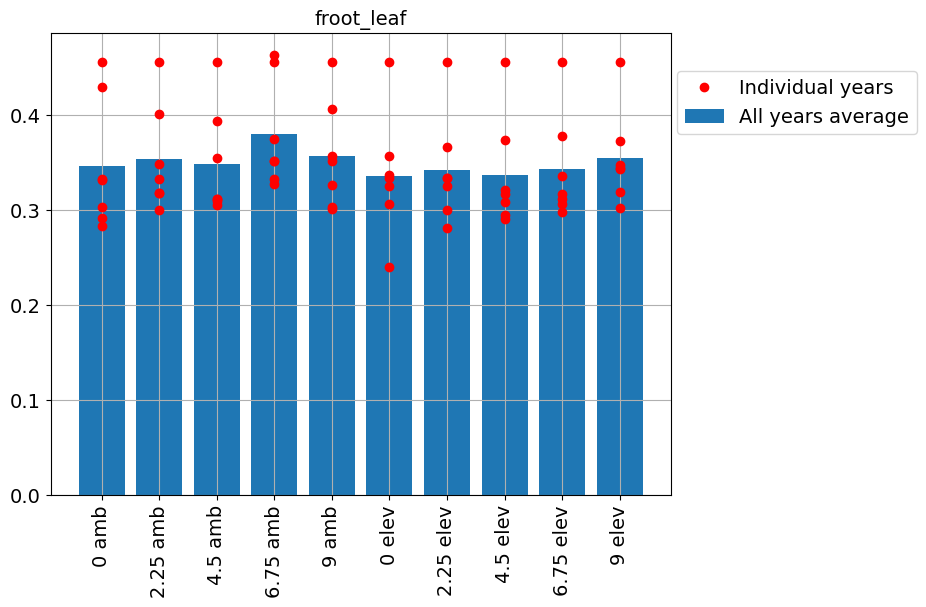

In [33]:
xticklabels = ['0 amb', '2.25 amb','4.5 amb', '6.75 amb', '9 amb', 
               '0 elev', '2.25 elev', '4.5 elev', '6.75 elev', '9 elev']
froot_leaf0 = 0.3
pft = '11'
fig, ax = plt.subplots(figsize = (8, 6))
temp = collection_gs[prefix].loc[:, (slice(None), 'ZWT_FROOT_PATCH', pft)
    ].resample('1Y').mean().loc[:, chambers_ordered['amb'] + chambers_ordered['elev']]
temp = temp * froot_leaf0
temp.columns = temp.columns.get_level_values(0)
plotID = np.broadcast_to(np.arange(temp.shape[1]).reshape(1, -1), temp.shape)
h, = ax.plot(plotID.reshape(-1), temp.values.reshape(-1), 'or')
h2 = ax.bar(plotID[0, :], np.mean(temp, axis = 0))
ax.set_xticks(np.arange(temp.shape[1]))
ax.set_xticklabels(xticklabels, rotation = 90)
ax.set_xlabel(None)
ax.set_title('froot_leaf')
ax.legend([h, h2], ['Individual years', 'All years average'], ncol = 1, loc = [1.01,0.78])
ax.grid(True)

In [19]:
# Water limitation
# Skip

"""diff = collection_gs[prefix_uptake] - collection_gs[prefix_default]

fig, axes = plt.subplots(3, 3, figsize = (15, 10), sharex = True)
plot = '10'
zwt = diff.loc[:, (plot, 'ZWT', '0')]
tbot = diff.loc[:, (plot, 'TBOT', '0')]
for i, pft in enumerate(['2','3','11']):
    # BTRAN
    ax = axes[i, 0]
    cpool = collection_gs[prefix_default].loc[:, (plot, 'BTRAN', pft)]
    h = ax.plot(cpool.index, cpool, color = 'r', label = 'Default')
    cpool = collection_gs[prefix_uptake].loc[:, (plot, 'BTRAN', pft)]
    h = ax.plot(cpool.index, cpool, color = 'b', label = 'V1')
    ax.set_title('$\Delta$ BTRAN')
    ax.grid(True)
    plt.setp(ax.get_xticklabels(), rotation = 90)
    if i == 0:
        ax.legend()

    # water table depth
    ax = axes[i, 1]
    cpool = collection_gs[prefix_default].loc[:, (plot, 'ZWT', '0')]
    h = ax.plot(cpool.index, cpool, color = 'r')
    cpool = collection_gs[prefix_uptake].loc[:, (plot, 'ZWT', '0')]
    h = ax.plot(cpool.index, cpool, color = 'b')
    ax.set_title('Water Table Depth (m)')
    ax.grid(True)
    plt.setp(ax.get_xticklabels(), rotation = 90)

    # soil moisture
    ax = axes[i, 2]
    cpool = collection_gs[prefix_default].loc[:, (plot, 'H2OSOI_ROOTFR', pft)]
    h = ax.plot(cpool.index, cpool, color = 'r')
    cpool = collection_gs[prefix_uptake].loc[:, (plot, 'H2OSOI_ROOTFR', pft)]
    h = ax.plot(cpool.index, cpool, color = 'b')
    ax.set_title('Soil water (m3 m-3)')
    ax.grid(True)
    plt.setp(ax.get_xticklabels(), rotation = 90) """

"diff = collection_gs[prefix_uptake] - collection_gs[prefix_default]\n\nfig, axes = plt.subplots(3, 3, figsize = (15, 10), sharex = True)\nplot = '10'\nzwt = diff.loc[:, (plot, 'ZWT', '0')]\ntbot = diff.loc[:, (plot, 'TBOT', '0')]\nfor i, pft in enumerate(['2','3','11']):\n    # BTRAN\n    ax = axes[i, 0]\n    cpool = collection_gs[prefix_default].loc[:, (plot, 'BTRAN', pft)]\n    h = ax.plot(cpool.index, cpool, color = 'r', label = 'Default')\n    cpool = collection_gs[prefix_uptake].loc[:, (plot, 'BTRAN', pft)]\n    h = ax.plot(cpool.index, cpool, color = 'b', label = 'V1')\n    ax.set_title('$\\Delta$ BTRAN')\n    ax.grid(True)\n    plt.setp(ax.get_xticklabels(), rotation = 90)\n    if i == 0:\n        ax.legend()\n\n    # water table depth\n    ax = axes[i, 1]\n    cpool = collection_gs[prefix_default].loc[:, (plot, 'ZWT', '0')]\n    h = ax.plot(cpool.index, cpool, color = 'r')\n    cpool = collection_gs[prefix_uptake].loc[:, (plot, 'ZWT', '0')]\n    h = ax.plot(cpool.index, cpool,

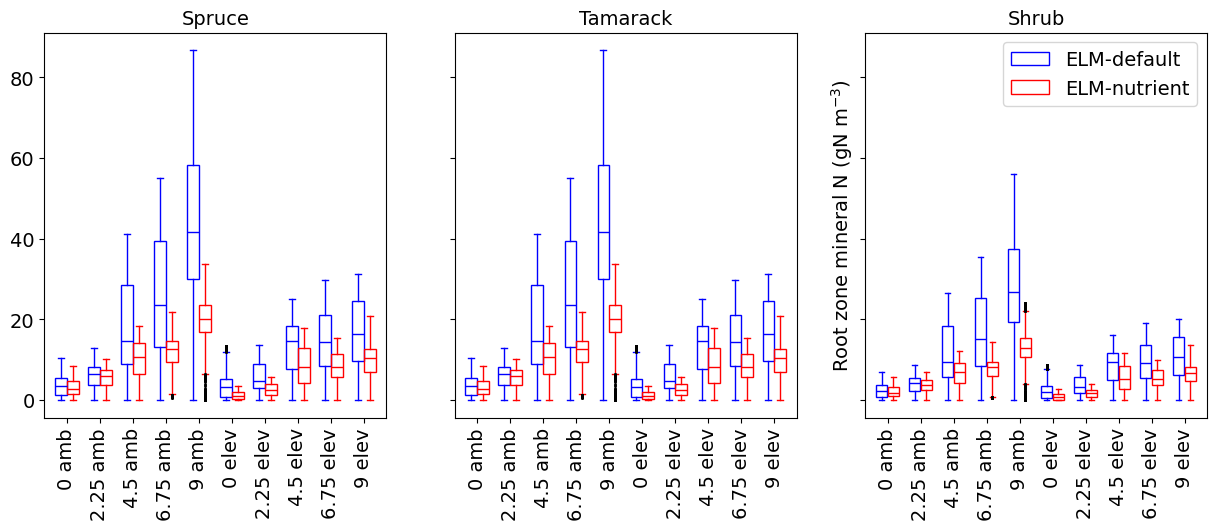

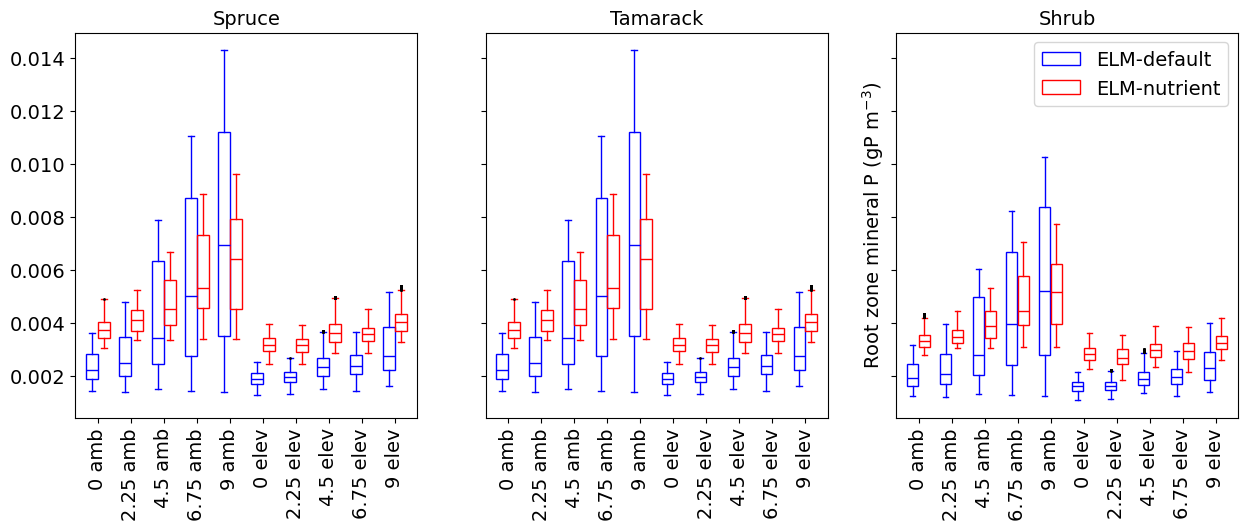

In [20]:
# Column nutrient level

xticklabels = ['0 amb', '2.25 amb','4.5 amb', '6.75 amb', '9 amb', 
               '0 elev', '2.25 elev', '4.5 elev', '6.75 elev', '9 elev']

for nu in ['N','P']:
    if nu == 'N':
        nu_var = 'SMINN_vr_ROOTFR'
    else:
        nu_var = 'SOLUTIONP_vr_ROOTFR'

    fig, axes = plt.subplots(1, 3, figsize = (15, 5), sharex = True, sharey = True)
    for i, (pft,name) in enumerate(zip(['2','3','11'],['Spruce','Tamarack','Shrub'])):
        ax = axes.flat[i]

        prefix = prefix_default
        temp = collection_gs[prefix].loc[:, (slice(None), nu_var, pft)
            ].loc[:, chambers_ordered['amb'] + chambers_ordered['elev']]
        temp.columns = temp.columns.get_level_values(0)
        bp1 = ax.boxplot(temp, positions = np.arange(temp.shape[1]) - 0.18, widths = 0.35,
                         patch_artist = True, flierprops = {'markersize': 1})

        prefix = prefix_uptake
        temp = collection_gs[prefix].loc[:, (slice(None), nu_var, pft)
            ].loc[:, chambers_ordered['amb'] + chambers_ordered['elev']]
        temp.columns = temp.columns.get_level_values(0)
        bp2 = ax.boxplot(temp, positions = np.arange(temp.shape[1]) + 0.18, widths = 0.35, 
                         patch_artist = True, flierprops = {'markersize': 1})

        for element in ['boxes', 'whiskers', 'fliers', 'means', 'medians', 'caps']:
            plt.setp(bp1[element], color='b')
            plt.setp(bp2[element], color='r')
        for patch in bp1['boxes']:
            patch.set_facecolor('none')
        for patch in bp2['boxes']:
            patch.set_facecolor('none')

        if i == 2:
            ax.set_ylabel(f'Root zone mineral {nu} (g{nu}' + ' m$^{-3}$)')
            ax.legend([bp1["boxes"][0], bp2["boxes"][0]], ['ELM-default', 'ELM-nutrient'], 
                      loc='upper right')

        #if nu == 'N':
        #    ax.set_ylim([0, 20])
        #else:
        #    ax.set_ylim([0, 0.006])

        ax.set_xticks(np.arange(temp.shape[1]))
        ax.set_xticklabels(xticklabels, rotation = 90)
        ax.set_xlabel(None)
        ax.set_title(name)

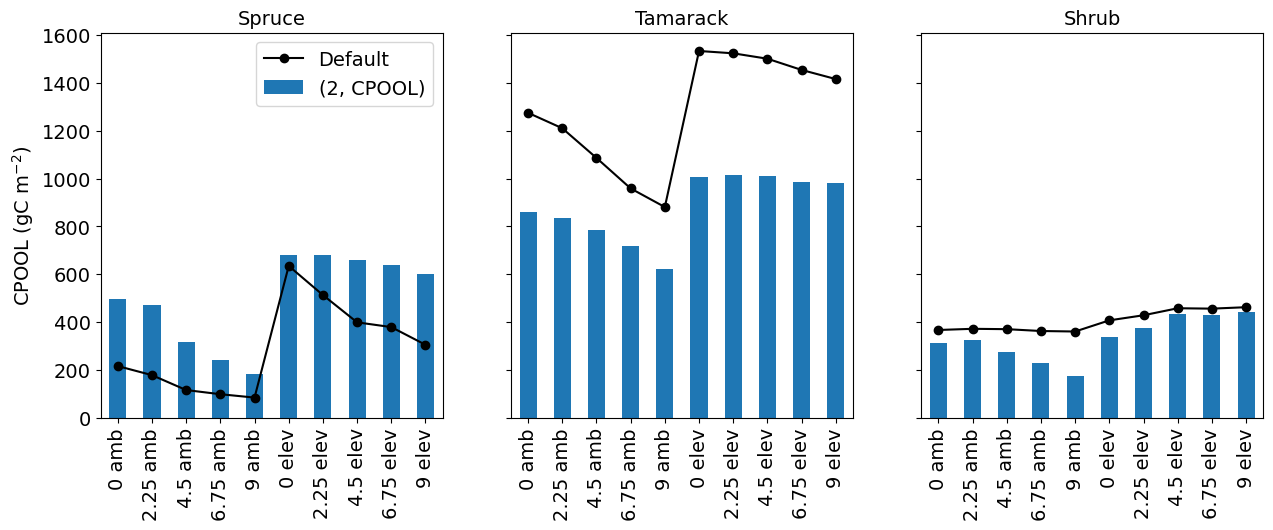

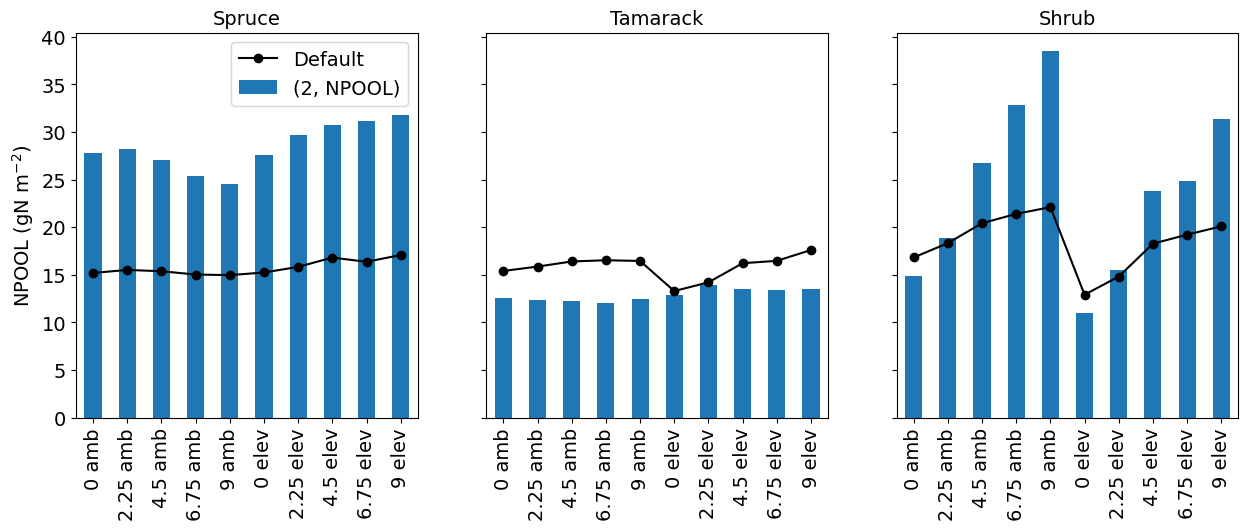

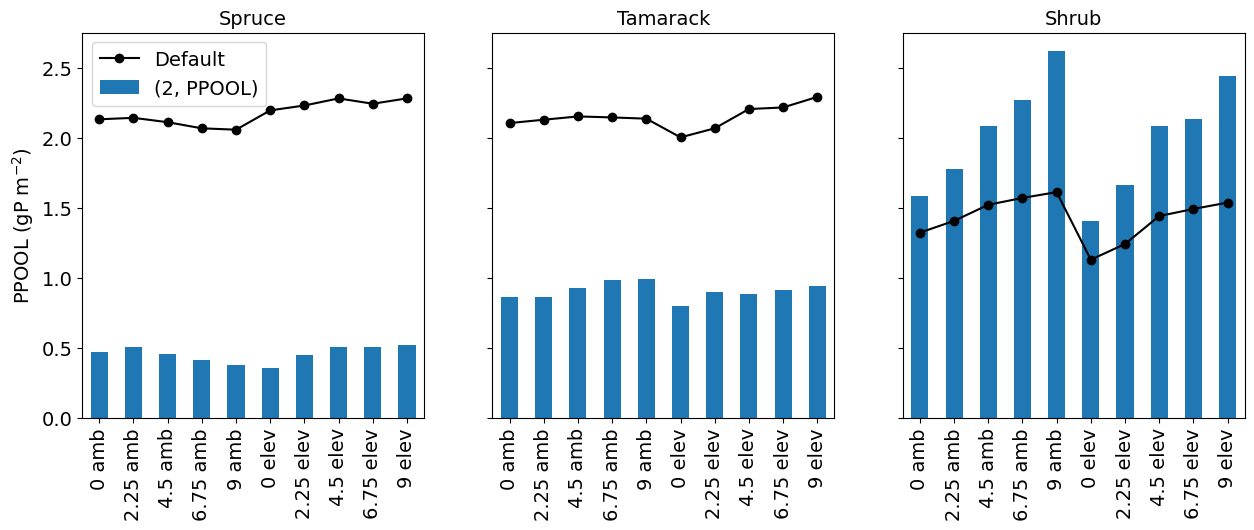

In [21]:
# CPOOL & NPOOL & PPOOL sizes
xticklabels = ['0 amb', '2.25 amb','4.5 amb', '6.75 amb', '9 amb', 
               '0 elev', '2.25 elev', '4.5 elev', '6.75 elev', '9 elev']

for nu in ['C','N','P']:
    fig, axes = plt.subplots(1, 3, figsize = (15, 5), sharex = True, sharey = True)
    for i, (pft,name) in enumerate(zip(['2','3','11'],['Spruce','Tamarack','Shrub'])):
        ax = axes.flat[i]

        prefix = prefix_default
        temp = collection_gs[prefix].mean(axis = 0).unstack().unstack( \
            ).loc[chambers_ordered['amb'] + chambers_ordered['elev'], :]
        xpool = temp.loc[:, (pft, f'{nu}POOL')]
        ax.plot(range(len(xpool)), xpool, '-ko', label = 'Default')

        prefix = prefix_uptake
        temp2 = collection_gs[prefix].mean(axis = 0).unstack().unstack( \
            ).loc[chambers_ordered['amb'] + chambers_ordered['elev'], :]
        xpool2 = temp2.loc[:, (pft, f'{nu}POOL')]

        #print(nu, pft, name)
        #print(retemp)

        if i == 0:
            xpool2.plot(kind='bar', stacked=True, ax = ax)
        else:
            xpool2.plot(kind='bar', stacked=True, ax = ax, legend = False)

        if i == 0:
            ax.set_ylabel(f'{nu}POOL (g{nu}' + ' m$^{-2}$)')
            ax.legend()

        ax.set_xticklabels(xticklabels)
        ax.set_xlabel(None)
        ax.set_title(name)

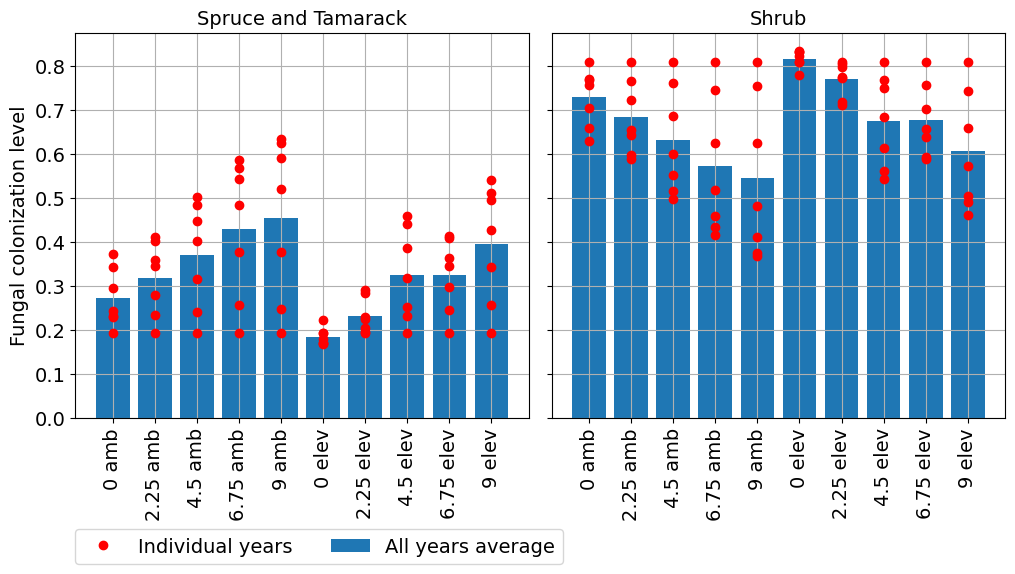

In [32]:
# Fungi inhibition on nutrient uptake

xticklabels = ['0 amb', '2.25 amb','4.5 amb', '6.75 amb', '9 amb', 
               '0 elev', '2.25 elev', '4.5 elev', '6.75 elev', '9 elev']
prefix = prefix_uptake

fig, axes = plt.subplots(1, 2, figsize = (12, 5), sharex = True, sharey = True)
fig.subplots_adjust(wspace = 0.05)
for i, (pft,name) in enumerate(zip(['2','11'],['Spruce','Shrub'])):
    ax = axes.flat[i]

    temp = collection_gs[prefix].loc[:, (slice(None), 'FUNGI_INHIB_PATCH', pft)
        ].resample('1Y').mean().loc[:, chambers_ordered['amb'] + chambers_ordered['elev']]
    temp.columns = temp.columns.get_level_values(0)
    plotID = np.broadcast_to(np.arange(temp.shape[1]).reshape(1, -1), temp.shape)
    h, = ax.plot(plotID.reshape(-1), temp.values.reshape(-1), 'or')
    h2 = ax.bar(plotID[0, :], np.mean(temp, axis = 0))

    if i == 0:
        ax.set_ylabel('Fungal colonization level')
        ax.legend([h, h2], ['Individual years', 'All years average'], ncol = 2, loc = [0, -0.38])

    ax.set_xticks(np.arange(temp.shape[1]))
    ax.set_xticklabels(xticklabels, rotation = 90)
    ax.set_xlabel(None)
    if i == 0:
        ax.set_title('Spruce and Tamarack')
    else:
        ax.set_title(name)
    ax.grid(True)

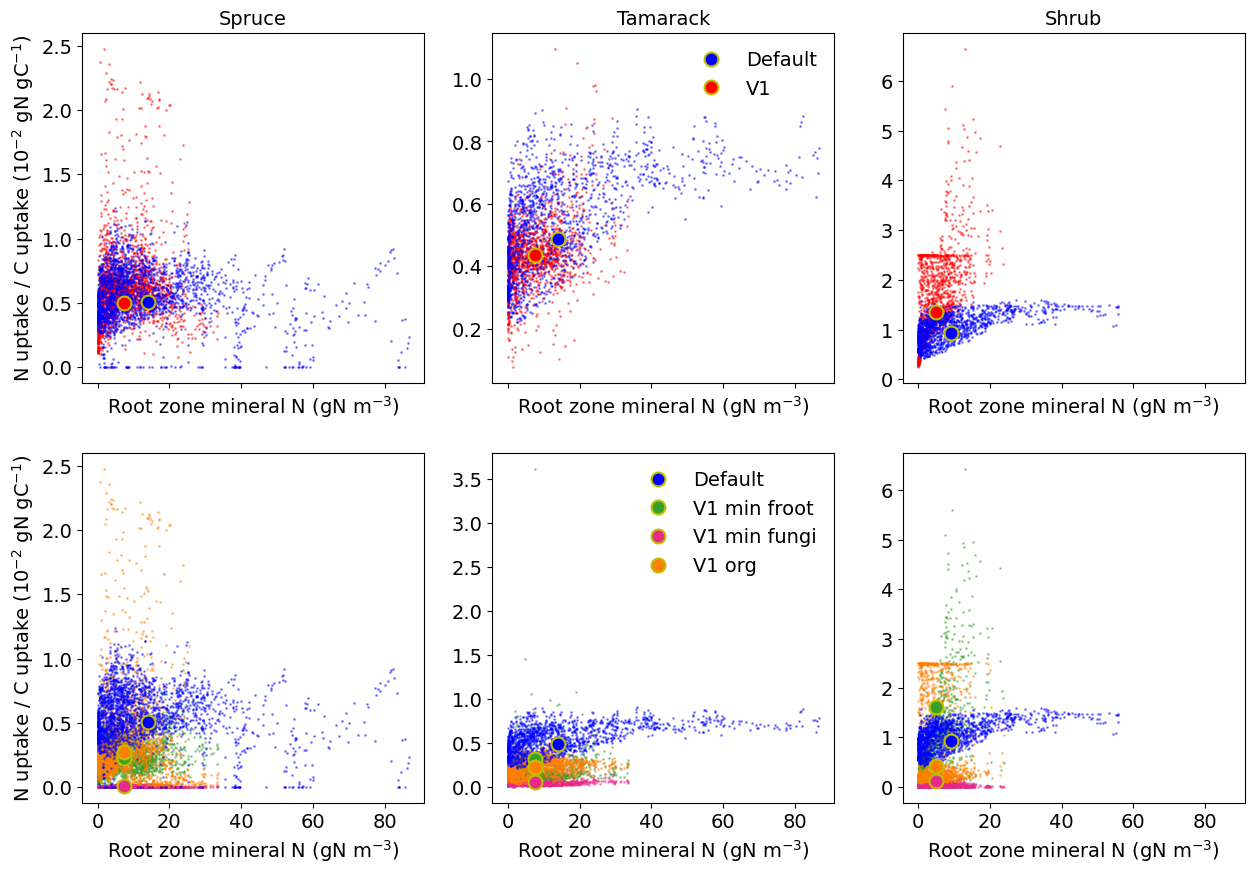

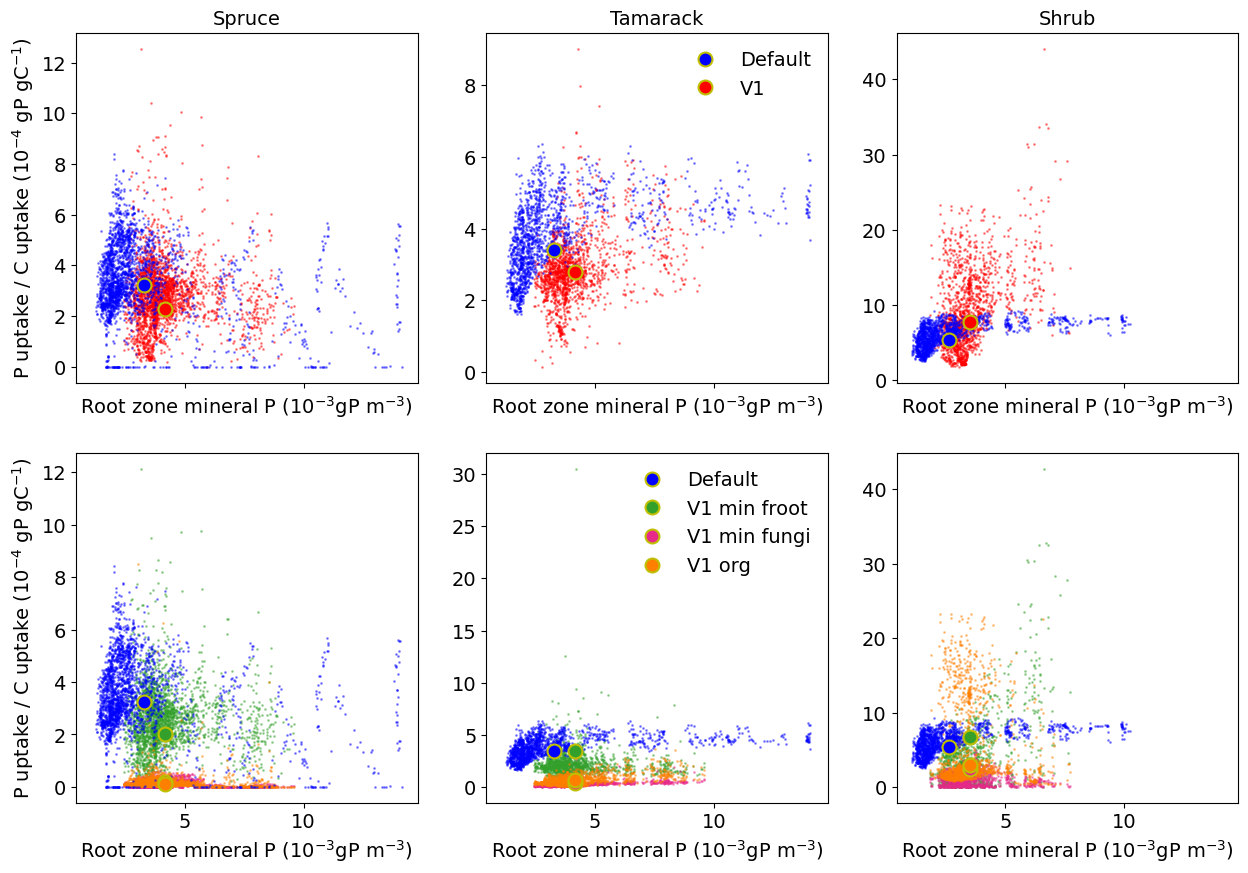

In [23]:
# Mineral + organic nutrient uptake/C assimilation
for nu in ['N','P']:
    if nu == 'N':
        nu_var = 'SMINN_vr_ROOTFR'
    else:
        nu_var = 'SOLUTIONP_vr_ROOTFR'

    fig, axes = plt.subplots(2, 3, figsize = (15, 10), sharex = True, sharey = False)
    for i, (pft,name) in enumerate(zip(['2','3','11'],['Spruce','Tamarack','Shrub'])):
        for j in range(2):
            ax = axes[j, i]
            for prefix, pname, colr in zip(prefix_list, ['Default', 'V1'], ['b','r']):
                sminn = collection_gs[prefix].loc[:, (slice(None), nu_var, pft)]
                sminn = sminn.resample('10D').mean()
                sminn_mean = sminn.mean().mean()

                cdemand = collection_gs[prefix].loc[:, (slice(None), 'AVAILC', pft)]

                smin_uptake = collection_gs[prefix].loc[:, (slice(None), 
                                                            f'SMIN{nu}_TO_{nu}POOL', pft)]
                min_cpool = smin_uptake.resample('10D').mean() / \
                    cdemand.resample('10D').mean().values
                min_cpool_mean = smin_uptake.mean().mean() / cdemand.mean().mean()
                if nu == 'N':
                    min_cpool = min_cpool * 1e2
                    min_cpool_mean = min_cpool_mean * 1e2
                elif nu == 'P':
                    sminn = sminn * 1e3
                    sminn_mean = sminn_mean * 1e3
                    min_cpool = min_cpool * 1e4
                    min_cpool_mean = min_cpool_mean * 1e4

                if pname == 'V1':
                    min_uptake_root = collection_gs[prefix].loc[:, (slice(None), 
                        f'FROOT_{nu}DEMAND_POT', pft)] / collection_gs[prefix].loc[:, 
                        (slice(None), f'PLANT_{nu}DEMAND_POT', pft)].values * smin_uptake.values
                    min_uptake_fungi = collection_gs[prefix].loc[:, (slice(None), 
                        f'FUNGI_{nu}DEMAND_POT', pft)] / collection_gs[prefix].loc[:, 
                        (slice(None), f'PLANT_{nu}DEMAND_POT', pft)].values * smin_uptake.values
                    min_cpool_root = min_uptake_root.resample('10D').mean() / \
                    cdemand.resample('10D').mean().values
                    min_cpool_fungi = min_uptake_fungi.resample('10D').mean() / \
                    cdemand.resample('10D').mean().values
                    min_cpool_root_mean = min_uptake_root.mean().mean() / cdemand.mean().mean()
                    min_cpool_fungi_mean = min_uptake_fungi.mean().mean() / cdemand.mean().mean()
                    if nu == 'N':
                        min_cpool_root = min_cpool_root * 1e2
                        min_cpool_fungi = min_cpool_fungi * 1e2
                        min_cpool_fungi_mean = min_cpool_fungi_mean * 1e2
                        min_cpool_root_mean = min_cpool_root_mean * 1e2
                    elif nu == 'P':
                        min_cpool_root = min_cpool_root * 1e4
                        min_cpool_fungi = min_cpool_fungi * 1e4
                        min_cpool_fungi_mean = min_cpool_fungi_mean * 1e4
                        min_cpool_root_mean = min_cpool_root_mean * 1e4

                    sorg_uptake = collection_gs[prefix].loc[:, \
                        (slice(None), f'FUNGI_SOM_TO_{nu}POOL', pft)]
                    org_cpool = sorg_uptake.resample('10D').mean() / \
                        cdemand.resample('10D').mean().values
                    org_cpool_mean = sorg_uptake.mean().mean() / cdemand.mean().mean()
                    if nu == 'N':
                        org_cpool = org_cpool * 1e2
                        org_cpool_mean = org_cpool_mean * 1e2
                    elif nu == 'P':
                        org_cpool = org_cpool * 1e4
                        org_cpool_mean = org_cpool_mean * 1e4

                if pname == 'Default':
                    h = ax.plot(sminn.values.reshape(-1), min_cpool.values.reshape(-1), 'o',
                                color = colr, markersize = 1, alpha = 0.4)
                    ax.plot(sminn_mean, min_cpool_mean, 'o',
                            color = colr, markersize = 10, markeredgecolor = 'y',
                            markeredgewidth = 1.5, label = pname)
                else:
                    if j == 0:
                        h = ax.plot(sminn.values.reshape(-1), 
                                    (org_cpool.values + min_cpool).values.reshape(-1), 'o',
                                    color = colr, markersize = 1, alpha = 0.4, 
                                    zorder = 1)
                        ax.plot(sminn_mean, min_cpool_mean + org_cpool_mean, 'o',
                                color = colr, markersize = 10, markeredgecolor = 'y', 
                                zorder = 3, markeredgewidth = 1.5, label = pname)
                    else:
                        h = ax.plot(sminn.values.reshape(-1), 
                                    (min_cpool_root).values.reshape(-1), 'o',
                                    color = '#33a02c', markersize = 1,
                                    alpha = 0.4, zorder = 1)
                        ax.plot(sminn_mean, min_cpool_root_mean, 'o',
                                color = '#33a02c', markersize = 10, markeredgecolor = 'y',
                                zorder = 3, markeredgewidth = 1.5, label = f'{pname} min froot')
                        h = ax.plot(sminn.values.reshape(-1), 
                                    (min_cpool_fungi).values.reshape(-1), 'o',
                                    color = '#e7298a', markersize = 1,
                                    alpha = 0.4, zorder = 1)
                        ax.plot(sminn_mean, min_cpool_fungi_mean, 'o',
                                color = '#e7298a', markersize = 10, markeredgecolor = 'y',
                                zorder = 3, markeredgewidth = 1.5, label = f'{pname} min fungi')
                        h = ax.plot(sminn.values.reshape(-1), 
                                    (org_cpool).values.reshape(-1), 'o',
                                    color = '#ff7f00', markersize = 1,
                                    alpha = 0.4, zorder = 1)
                        ax.plot(sminn_mean, org_cpool_mean, 'o', label = f'{pname} org', 
                                color = '#ff7f00', markersize = 10, markeredgecolor = 'y',
                                zorder = 3, markeredgewidth = 1.5)

            if i == 0:
                if nu == 'N':
                    ax.set_ylabel(f'{nu} uptake / C uptake (' + '10$^{-2}$ ' + f'g{nu} ' + 'gC$^{-1}$)')
                else:
                    ax.set_ylabel(f'{nu} uptake / C uptake (' + '10$^{-4}$ ' + f'g{nu} ' + 'gC$^{-1}$)')

            if i == 1:
                ax.legend(frameon = False)

            if j == 0:
                ax.set_title(name)

            if nu == 'N':
                ax.set_xlabel(f'Root zone mineral {nu} (g{nu} ' + 'm$^{-3}$)')
            else:
                ax.set_xlabel(f'Root zone mineral {nu} (' + '10$^{-3}$' + f'g{nu} ' + 'm$^{-3}$)')

/tmp/ipykernel_1053841/3888523525.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = get_cmap('viridis_r')
/tmp/ipykernel_1053841/3888523525.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = get_cmap('magma_r')
/tmp/ipykernel_1053841/3888523525.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(range(1,13))
/tmp/ipykernel_1053841/3888523525.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(range(1,13))
/tmp/ipykernel_10538

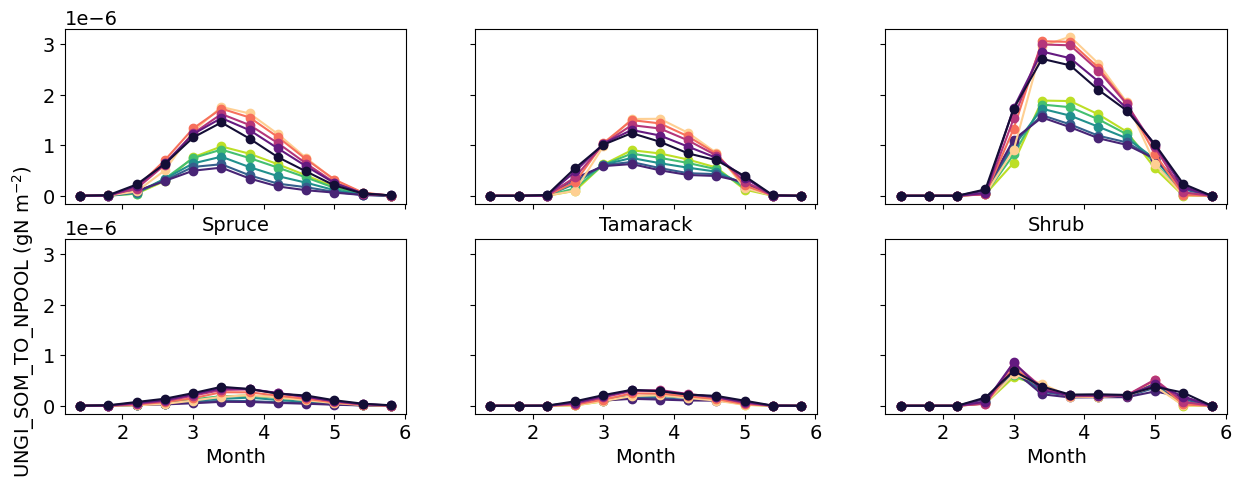

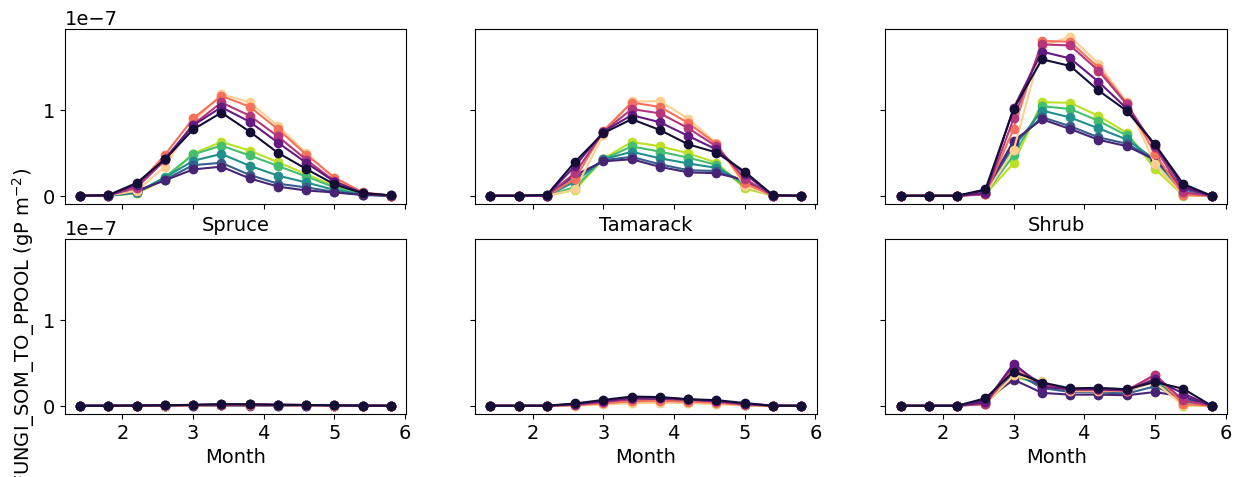

In [24]:
# Seasonality in N/P uptake 
cmap = get_cmap('viridis_r')
clist_amb = [cmap((i+0.5)/5) for i in range(5)]
cmap = get_cmap('magma_r')
clist_elev = [cmap((i+0.5)/5) for i in range(5)]

for nu in ['N','P']:
    fig, axes = plt.subplots(2, 3, figsize = (15, 5), sharex = True, sharey = True)
    for i, (pft,name) in enumerate(zip(['2','3','11'],['Spruce','Tamarack','Shrub'])):

        ax = axes[0, i]
        prefix = prefix_default
        temp = collection_gs[prefix].loc[:, (slice(None), f'PLANT_{nu}DEMAND', pft)
                ].groupby(collection_gs[prefix].index.month).mean()
        temp.columns = temp.columns.droplevel([1,2])

        for j,c in enumerate(chambers_ordered['amb']):
            ax.plot(range(1, 13), temp.loc[:, c], '-o', color = clist_amb[j])
        for j,c in enumerate(chambers_ordered['elev']):
            ax.plot(range(1, 13), temp.loc[:, c], '-o', color = clist_elev[j])


        ax = axes[1, i]
        prefix = prefix_uptake
        temp = collection_gs[prefix].loc[:, (slice(None), f'FUNGI_SOM_TO_{nu}POOL', pft)
                ].groupby(collection_gs[prefix].index.month).mean()
        temp.columns = temp.columns.droplevel([1,2])

        for j,c in enumerate(chambers_ordered['amb']):
            ax.plot(range(1, 13), temp.loc[:, c], '-o', color = clist_amb[j])
        for j,c in enumerate(chambers_ordered['elev']):
            ax.plot(range(1, 13), temp.loc[:, c], '-o', color = clist_elev[j])

        if i == 0:
            ax.set_ylabel(f'FUNGI_SOM_TO_{nu}POOL (g{nu}' + ' m$^{-2}$)')
            #ax.legend()

        ax.set_xticklabels(range(1,13))
        ax.set_xlabel('Month')
        ax.set_title(name)

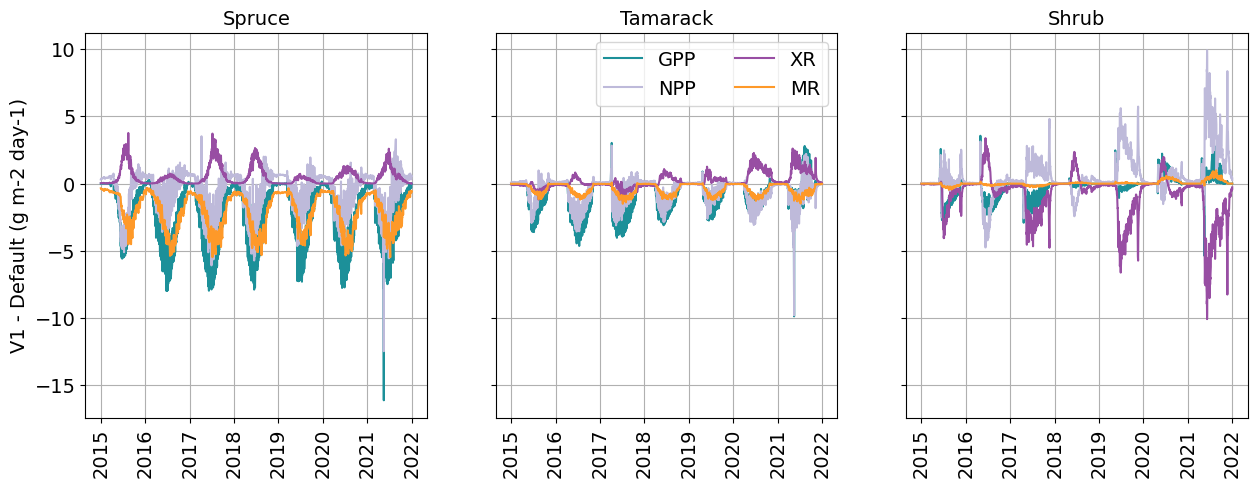

In [25]:
# !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!! Need to find out where this term went
# coz it is different and not part of XR
# xsmrpool_recover

color_list = ['#1c9099', '#bebada', '#984ea3', '#fe9929']

fig, axes = plt.subplots(1, 3, figsize = (15, 5), sharex = True, sharey = True)
plot = '10'
for i, (pft,name) in enumerate(zip(['2','3','11'],['Spruce','Tamarack','Shrub'])):
    ax = axes.flat[i]
    for j, var in enumerate(['GPP', 'NPP', 'XR', 'MR']):
        default = collection_gs[prefix_default].loc[:, (plot, var, pft)] * 86400
        uptake = collection_gs[prefix_uptake].loc[:, (plot, var, pft)] * 86400
        h = ax.plot(default.index, uptake - default, label = var, color = color_list[j])
        ax.grid(True)
        plt.setp(ax.get_xticklabels(), rotation = 90)
        ax.set_title(name)
    if i == 0:
        ax.set_ylabel(f'V1 - Default (g m-2 day-1)')
    if i == 1:
        ax.legend(ncol = 2)

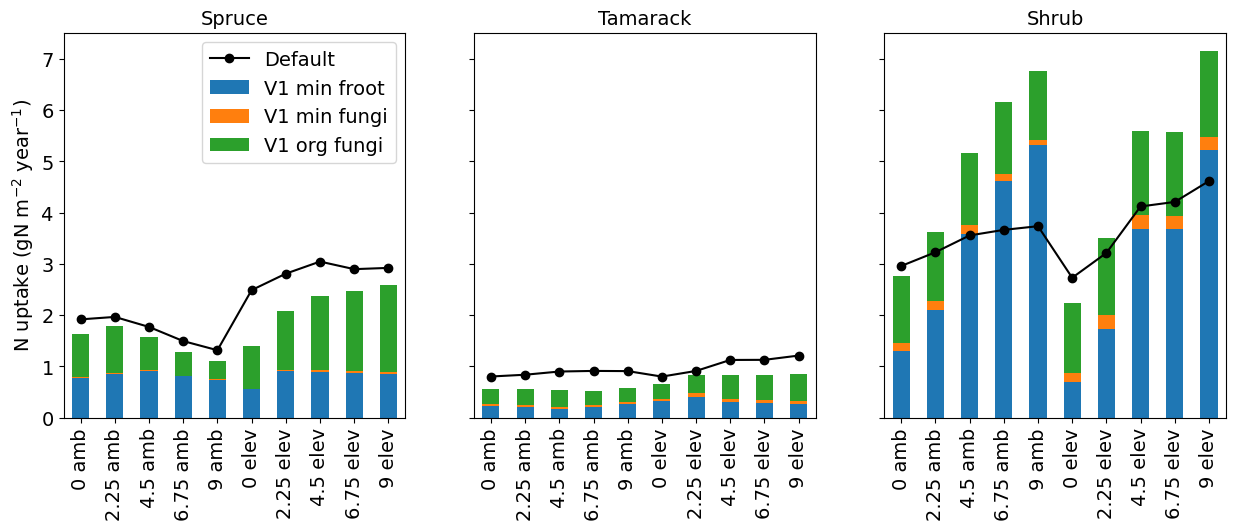

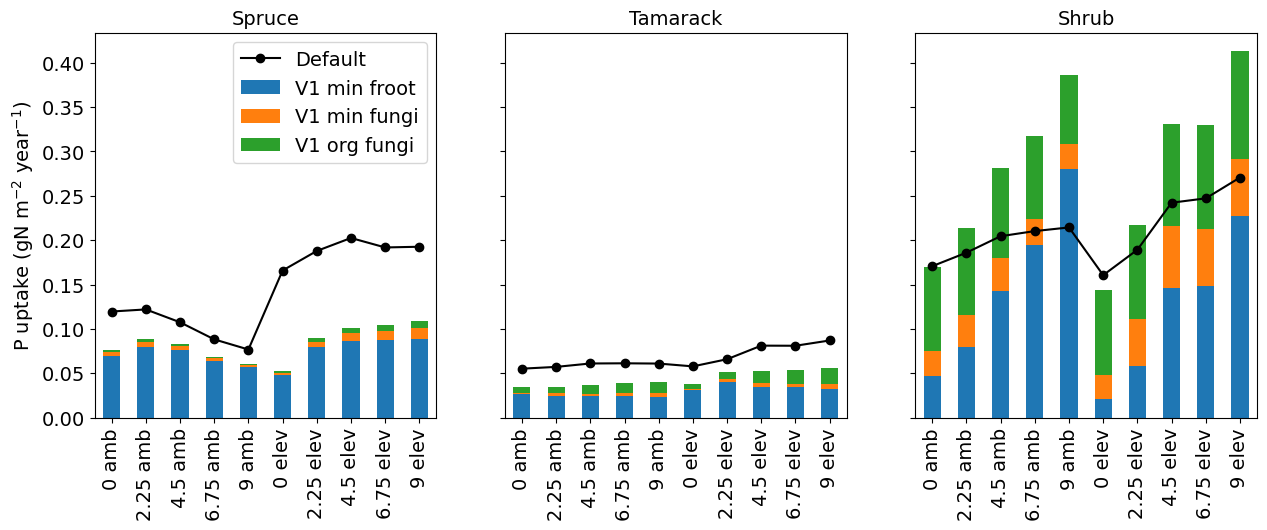

In [26]:
xticklabels = ['0 amb', '2.25 amb','4.5 amb', '6.75 amb', '9 amb', 
               '0 elev', '2.25 elev', '4.5 elev', '6.75 elev', '9 elev']
pft_frac = [0.36, 0.14, 0.25, 0.25]

for nu in ['N','P']:
    fig, axes = plt.subplots(1, 3, figsize = (15, 5), sharex = True, sharey = True)
    for i, (pft,name) in enumerate(zip(['2','3','11'],['Spruce','Tamarack','Shrub'])):
        ax = axes.flat[i]

        temp = collection_gs[prefix_default].mean(axis = 0).unstack().unstack( \
            ).loc[chambers_ordered['amb'] + chambers_ordered['elev'], :]
        froot_min = temp.loc[:, (pft, f'SMIN{nu}_TO_{nu}POOL')] * 86400 * 365 * pft_frac[i]
        ax.plot(range(len(froot_min)), froot_min, '-ko', label = 'Default')

        temp = collection_gs[prefix_uptake].mean(axis = 0).unstack().unstack( \
            ).loc[chambers_ordered['amb'] + chambers_ordered['elev'], :]
        froot_min = temp.loc[:, (pft, f'SMIN{nu}_TO_{nu}POOL')] / \
            temp.loc[:, (pft, f'PLANT_{nu}DEMAND_POT')] * \
            temp.loc[:, (pft, f'FROOT_{nu}DEMAND_POT')]
        fungi_min = temp.loc[:, (pft, f'SMIN{nu}_TO_{nu}POOL')] / \
            temp.loc[:, (pft, f'PLANT_{nu}DEMAND_POT')] * \
            temp.loc[:, (pft, f'FUNGI_{nu}DEMAND_POT')]
        fungi_som = temp.loc[:, (pft, f'FUNGI_SOM_TO_{nu}POOL')]
        retemp = pd.concat([froot_min, fungi_min, fungi_som], axis = 1) * 86400 * 365 * pft_frac[i]
        retemp.columns = ['V1 min froot', 'V1 min fungi', 'V1 org fungi']

        #print(nu, pft, name)
        #print(retemp)

        if i == 0:
            retemp.plot(kind='bar', stacked=True, ax = ax)
        else:
            retemp.plot(kind='bar', stacked=True, ax = ax, legend = False)

        if i == 0:
            ax.set_ylabel(f'{nu} uptake ' + '(gN m$^{-2}$ year$^{-1}$)')
            ax.legend()

        ax.set_xticklabels(xticklabels)
        ax.set_xlabel(None)
        ax.set_title(name)

# Soren thinks most of the nutrients from shrub should be from the fungi
# The result is okay. We can discuss it. 

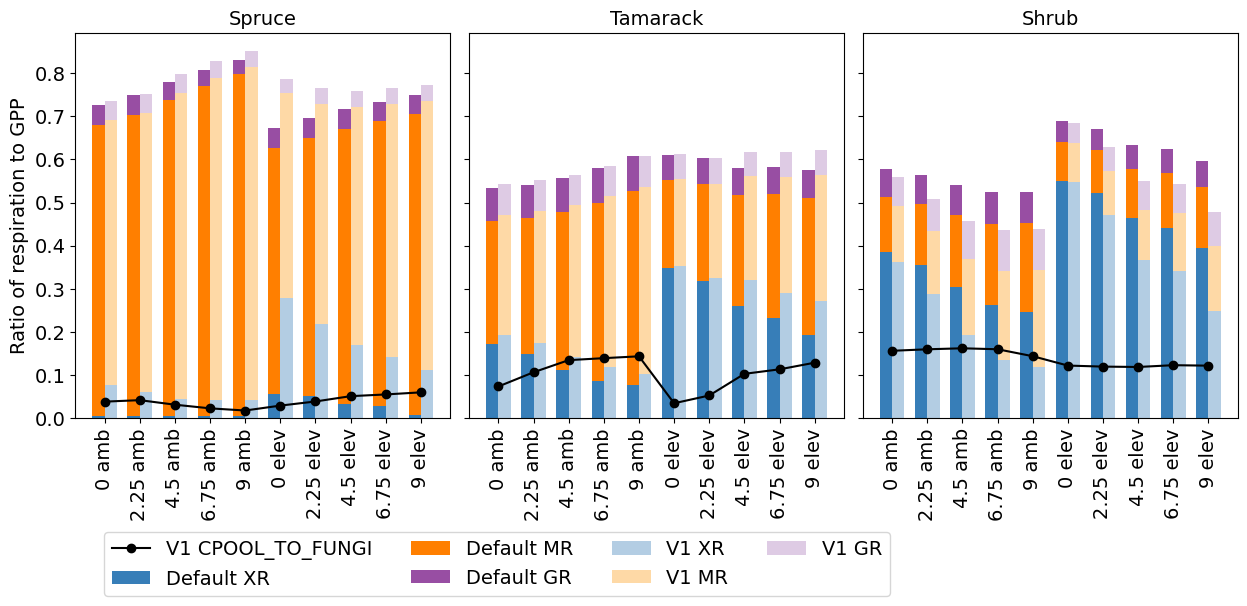

In [27]:
                                                                                                                            def create_multi_level_stacked_barplot(ax, df):
    """
    Create a stacked bar plot from a DataFrame with two-level columns.
    The first level columns are plotted as separate groups,
    and the second level columns are stacked within each group.

    Parameters:
    ax (matplotlib.axes.Axes): The axis to plot on
    df (pandas.DataFrame): The data to plot, with multi-level columns
    """
    # Get the unique values from the first level of the column index
    top_level = df.columns.get_level_values(0).unique()
    
    # Set up the x locations for the groups
    x = np.arange(len(df.index))
    width = 0.35  # Width of each bar group
    color_list = [
        '#377eb8', '#ff7f00', '#984ea3',
        '#b3cde3', '#fed9a6', '#decbe4'
    ]

    for i, group in enumerate(top_level):
        bottom = np.zeros(len(df.index))
        for j,col in enumerate(df[group].columns):
            ax.bar(x + i*width - width/2, df[group][col], width, bottom=bottom, 
                   label=f'{group} {col}', color=color_list[i*3+j])
            bottom += df[group][col]

xticklabels = ['0 amb', '2.25 amb','4.5 amb', '6.75 amb', '9 amb', 
               '0 elev', '2.25 elev', '4.5 elev', '6.75 elev', '9 elev']

fig, axes = plt.subplots(1, 3, figsize = (15, 5), sharex = True, sharey = True)
fig.subplots_adjust(wspace = 0.05)
for i, (pft,name) in enumerate(zip(['2','3','11'],['Spruce','Tamarack','Shrub'])):

    prefix = prefix_default
    temp = collection_gs[prefix].mean(axis = 0).unstack().unstack( \
        ).loc[chambers_ordered['amb'] + chambers_ordered['elev'], :]
    xr = temp.loc[:, (pft, 'XR')] / temp.loc[:, (pft, 'GPP')]
    mr = temp.loc[:, (pft, 'MR')] / temp.loc[:, (pft, 'GPP')]
    gr = temp.loc[:, (pft, 'GR')] / temp.loc[:, (pft, 'GPP')]
    retemp = pd.concat([xr, mr, gr], axis = 1)
    retemp.columns = ['XR', 'MR', 'GR']

    prefix = prefix_uptake
    temp = collection_gs[prefix].mean(axis = 0).unstack().unstack( \
        ).loc[chambers_ordered['amb'] + chambers_ordered['elev'], :]
    cpool_to_fungi = temp.loc[:, (pft, 'CPOOL_TO_FUNGI')] / temp.loc[:, (pft, 'GPP')]
    xr = temp.loc[:, (pft, 'XR')] / temp.loc[:, (pft, 'GPP')]
    mr = temp.loc[:, (pft, 'MR')] / temp.loc[:, (pft, 'GPP')]
    gr = temp.loc[:, (pft, 'GR')] / temp.loc[:, (pft, 'GPP')]
    retemp2 = pd.concat([xr, mr, gr], axis = 1)
    retemp2.columns = ['XR', 'MR', 'GR']

    retemp3 = pd.concat([retemp, retemp2], axis = 1, keys = ['Default', 'V1'])

    ax = axes.flat[i]
    create_multi_level_stacked_barplot(ax, retemp3)
    ax.plot(np.arange(temp.shape[0]), 
            cpool_to_fungi, '-o', color = 'k', 
            label = 'V1 CPOOL_TO_FUNGI')

    if i == 0:
        ax.set_ylabel('Ratio of respiration to GPP')
        ax.legend(ncol = 4, bbox_to_anchor=(0.05, -0.27), loc='upper left')

    ax.set_xticks(range(len(xticklabels)))
    ax.set_xticklabels(xticklabels, rotation = 90)
    ax.set_xlabel(None)
    ax.set_title(name)

In [28]:
###############################################################
# Sensitivity plots
###############################################################

# the dimensions are:
#   N sims x VAR_LIST x (amb, elev) x (mean, mean_std, slope, ts * slope_std)
prefix_list = ['UQ_20231113'] # , 'UQ_20240312_test20241017']
N_list = [4000] # , 3125]
BLOCK_LIST = [200] # , 125]
VAR_LIST = ['AGBiomass_Spruce', 'AGBiomass_Tamarack', 'AGBiomass_Shrub',
            'AGNPPtoBiomass_Spruce', 'AGNPPtoBiomass_Tamarack', 'AGNPPtoBiomass_Shrub',
            'AGNPP_Spruce', 'AGNPP_Tamarack', 'AGNPP_Shrub', 'NPP_moss',
            'BGNPP_TreeShrub', 'BGtoAG_TreeShrub', 'HR', 'NEE'] # , 'TOTSOMC']

collection_obs = uq_get_obs(VAR_LIST)

collection_sim = {}
for N, BLOCK, prefix in zip(N_list, BLOCK_LIST, prefix_list):
    collect = np.empty([N, len(VAR_LIST), 2, 4], float)
    for b in range(0, N // BLOCK):
        collect[(b*BLOCK):((b + 1)*BLOCK), :, :, :] = np.load(os.path.join(
            os.environ['PROJDIR'], 'ELM_Phenology', 'output', "extract", prefix,
            f"ensemble_collection_part{b:03g}.bin"), allow_pickle=True)[:, 1:, :, :] # TEMPORARY
    # convert Inf's to NaN
    collect = np.where(~((collect == np.inf) | (collect == -np.inf)), collect, np.nan)
    # revert the signs of NEE & HR to be compatible with Paul's data
    # collect[:, -3:-1, :, :] = - collect[:, -3:-1, :, :]
    # TEMPORARY
    collect[:, -2:, :, :] = - collect[:, -2:, :, :]

    collection_sim[prefix] = collect

collection_sim_target = {}
for prefix in [prefix_default, prefix_uptake]:
    collection_sim_target[prefix] = uq_get_sim(prefix, VAR_LIST)

/autofs/nccsopen-svm1_home/ywo/Git/phenology_elm/utils/analysis.py:1107: PerformanceWarning: indexing past lexsort depth may impact performance.
  sim_tair = sim_data.loc['average', 'Tair']
/autofs/nccsopen-svm1_home/ywo/Git/phenology_elm/utils/analysis.py:1107: PerformanceWarning: indexing past lexsort depth may impact performance.
  sim_tair = sim_data.loc['average', 'Tair']


/tmp/ipykernel_1053841/3584452539.py:100: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "-or" (-> color='r'). The keyword argument will take precedence.
  h4[p], = ax.plot(sims_target_slope[prefix][0, :], '-or', color = clist[2 + p])


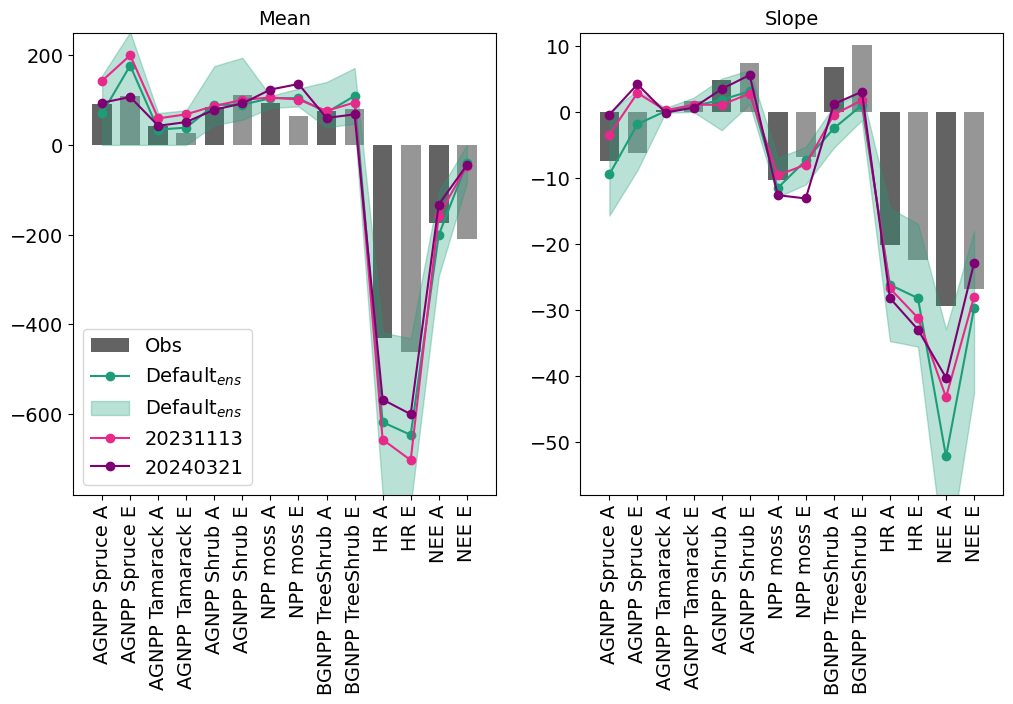

In [29]:
# Make a nicer graph that overlays the top 10 best runs of each prefix_list
VAR_SUBSET =  ['AGNPP_Spruce','AGNPP_Tamarack','AGNPP_Shrub', 'NPP_moss',
               'BGNPP_TreeShrub','HR','NEE']
xticklabels = [var.replace('_',' ')+f' {co2}' for var in VAR_SUBSET for co2 in ['A', 'E']]
ind_list = [] # the index to VAR_SUBSET that we are interested in
for i,var in enumerate(VAR_LIST):
    if var in VAR_SUBSET:
        ind_list.append(i)
ind_list = np.array(ind_list)

#
n_best_ind = 50
obs_mean = collection_obs.values.reshape(-1, 2, 4)[ind_list, :, 0].reshape(1,-1)
obs_slope = collection_obs.values.reshape(-1, 2, 4)[ind_list, :, 2].reshape(1,-1)
sims_target_mean = {}
sims_target_slope = {}
for prefix in collection_sim_target:
    sims_target_mean[prefix] = collection_sim_target[prefix].values.reshape(-1, 2, 
        4)[ind_list, :, 0].reshape(1, -1)
    sims_target_slope[prefix] = collection_sim_target[prefix].values.reshape(-1, 2, 
        4)[ind_list, :, 2].reshape(1, -1)

#
fig, axes = plt.subplots(1, 2, figsize = (12, 6), sharex = True)
ax = axes[0]
h1 = ax.bar(np.arange(obs_mean.shape[1]), obs_mean[0, :], width = 0.7,
            color = ['#636363', '#969696'] * len(VAR_SUBSET))
ax.set_title('Mean')
ax = axes[1]
h1 = ax.bar(np.arange(obs_slope.shape[1]), obs_slope[0, :], width = 0.7,
            color = ['#636363', '#969696'] * len(VAR_SUBSET))
ax.set_title('Slope')

clist = ['#1b9e77', '#d95f02', '#e7298a', '#800074'] # '#1a80bb'
h2 = [None] * len(prefix_list)
h3 = [None] * len(prefix_list)
for p, prefix in enumerate(prefix_list):

    # the 2 is ACO2 and ECO2
    sim_mean = collection_sim[prefix][:, ind_list, :][:,:,:,0].reshape(-1, 2*len(ind_list))
    sim_slope = collection_sim[prefix][:, ind_list, :][:,:,:,2].reshape(-1, 2*len(ind_list))

    # find the best runs
    rmse_mean = np.sqrt(np.mean(np.power((sim_mean - obs_mean) / \
                                        (np.abs(obs_mean)) * 2, 2),
                                axis = 1))
    rmse_slope = np.sqrt(np.mean(np.power((sim_slope - obs_slope) / \
                                        (np.abs(obs_slope)) * 2, 2),
                                axis = 1))
    rmse_tot = np.sqrt((rmse_mean**2 + rmse_slope**2)/2)
    best_inds = np.argpartition(rmse_tot, n_best_ind)[:n_best_ind]

    sim_mean_bi = sim_mean[best_inds, :]
    sim_slope_bi = sim_slope[best_inds, :]

    ax = axes[0]
    if prefix == 'UQ_20240311_2':
        h2[p], = ax.plot(sim_mean[2461, :], '-o', color = clist[p])
    elif prefix == 'UQ_20231113':
        h2[p], = ax.plot(sim_mean[681, :], '-o', color = clist[p])
    elif prefix == 'UQ_20240312_test20241012':
        h2[p], = ax.plot(sim_mean[2, :], '-o', color = clist[p])
    elif prefix == 'UQ_20240312_test20241017':
        h2[p], = ax.plot(sim_mean[2851, :], '-o', color = clist[p])
    else:
        h2[p], = ax.plot(sim_mean_bi.mean(axis = 0), '-o', color = clist[p])
    h3[p] = ax.fill_between(np.arange(sim_mean_bi.shape[1]), 
                            np.min(sim_mean_bi, axis = 0),
                            np.max(sim_mean_bi, axis = 0), color = clist[p], alpha = 0.3)

    ax.set_xticks(np.arange(sim_mean_bi.shape[1]))
    ax.set_xticklabels(xticklabels, rotation = 90)
    ax.set_ylim([-780, 250])

    ax = axes[1]
    if prefix == 'UQ_20240311_2':
        h2[p], = ax.plot(sim_slope[2461, :], '-o', color = clist[p])
    elif prefix == 'UQ_20231113':
        h2[p], = ax.plot(sim_slope[681, :], '-o', color = clist[p])
    elif prefix == 'UQ_20240312_test20241012':
        h2[p], = ax.plot(sim_slope[2, :], '-o', color = clist[p])
    elif prefix == 'UQ_20240312_test20241013':
        h2[p], = ax.plot(sim_slope[900, :], '-o', color = clist[p])
    elif prefix == 'UQ_20240312_test20241017':
        h2[p], = ax.plot(sim_slope[2851, :], '-o', color = clist[p])
    else:
        h2[p], = ax.plot(sim_slope_bi.mean(axis = 0), '-o', color = clist[p])
    h3[p] = ax.fill_between(np.arange(sim_slope_bi.shape[1]), 
                            np.min(sim_slope_bi, axis = 0),
                            np.max(sim_slope_bi, axis = 0), color = clist[p], alpha = 0.3)
    ax.set_xticks(np.arange(sim_slope_bi.shape[1]))
    ax.set_xticklabels(xticklabels, rotation = 90)
    ax.set_ylim([-58, 12])

h4 = [None] * 2
for p, prefix in enumerate([prefix_default, prefix_uptake]):
    ax = axes[0]
    h4[p], = ax.plot(sims_target_mean[prefix][0, :], '-o', color = clist[2 + p])
    ax = axes[1]
    h4[p], = ax.plot(sims_target_slope[prefix][0, :], '-or', color = clist[2 + p])

ax = axes[0]
ax.legend([h1] + h2 + h3 + h4, ['Obs', 'Default$_{ens}$'] + \
          ['NU ' + p.split('_')[-1] for p in prefix_list[1:]] + \
          ['Default$_{ens}$'] + ['NU$_{ens}$' + p.split('_')[-1] for p in prefix_list[1:]] + 
          [f'{prefix_default}', f'{prefix_uptake}'],
          loc = 'lower left')